# Hierarchical Gibbs sampler — selected days

Fits Hoff's Chapter 8 hierarchical normal model (`model/README.md` §§4–7) to the **expanding-window** sufficient statistics: day 1 uses only day-1 commits, day *t* uses days 1 through *t*.

**Sampler.** The four full conditionals are closed form (normal / inverse-gamma), so this is a vectorized **NumPy Gibbs sampler** in `impact_model.gibbs` — the algorithm Hoff writes down, not NUTS. PyMC or NumPyro would be slower here and would not be Gibbs. Hyperpriors are the Section 10.6 values on the 1–10 score scale: μ<sub>0</sub> = 5, γ<sub>0</sub>² = 4, τ<sub>0</sub>² = 0.5, σ<sub>0</sub>² = 3, η<sub>0</sub> = ν<sub>0</sub> = 1.

**This notebook** times and diagnoses days **1, 5, 50, 90** (5,000 iterations, 1,000 burn-in), then redraws the contributor-mean series at those **four snapshots** using posterior means of θ<sub>j</sub> instead of raw ȳ<sub>j</sub>.

**How to run** (from `notebooks/`):

```bash
uv sync
uv run jupyter lab fit_gibbs.ipynb
```

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from github_etl.schemas import FINAL_COLUMNS, FinalCommitSchema
from impact_model import (
    daily_contributor_panel,
    fit_day,
    read_daily_panel,
    restore_list_columns,
    score_commits,
    write_daily_panel,
    write_scored_commits,
)
from impact_model.gibbs import GibbsFit

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

## 0. Load the daily panel

The Gibbs step never sees individual commits. It needs, for each contributor *j* on day *t*, the cumulative (*n*<sub>j</sub>, Σ *y*, Σ *y*²). Those live in `model/data/daily_contributor_panel.parquet`, built from scored commits validated by `ScoredCommitSchema` (a subclass of `github_etl.schemas.FinalCommitSchema`). If the parquet is missing, rebuild it from the ETL extract.

In [2]:
def find_repo_root() -> Path:
    here = Path.cwd().resolve()
    marker = Path("github_etl") / "src" / "github_etl" / "schemas.py"
    for candidate in (here, *here.parents):
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError("Run Jupyter from the repo root or notebooks/.")


REPO = find_repo_root()
DATA_DIR = REPO / "model" / "data"
PANEL_PATH = DATA_DIR / "daily_contributor_panel.parquet"
SCORED_PATH = DATA_DIR / "scored_commits.parquet"

if not PANEL_PATH.exists() or not SCORED_PATH.exists():
    raw = pd.read_parquet(REPO / "github_etl" / "data" / "contributor_commits.parquet")
    commits = FinalCommitSchema.validate(restore_list_columns(raw)[FINAL_COLUMNS])
    scored = score_commits(commits)
    write_scored_commits(scored, SCORED_PATH)
    write_daily_panel(daily_contributor_panel(scored), PANEL_PATH)
    print(f"wrote {SCORED_PATH.name} and {PANEL_PATH.name}")

panel = read_daily_panel(PANEL_PATH)
n_days = int(panel["day_index"].max())
print(f"loaded {PANEL_PATH}")
print(
    f"rows={len(panel):,}  days={n_days}  "
    f"({panel['day'].min().date()} → {panel['day'].max().date()})  "
    f"contributors ever={panel['contributor'].nunique()}"
)
print(panel.groupby("day_index").size().rename("m").loc[[1, 5, 50, 90]].to_string())

loaded /Users/steffen/Documents/posthog_contributor_impact/model/data/daily_contributor_panel.parquet
rows=14,756  days=91  (2026-05-20 → 2026-08-18)  contributors ever=210
day_index
1      23
5      80
50    174
90    208


## 1. Fit days 1, 5, 50, 90

5,000 iterations, first 1,000 discarded. One chain. Same seed for every day so timing is comparable. Expected bottleneck is Python loop overhead, not the linear algebra — each iteration is *O(m)* with *m* ≤ 210.

In [3]:
DIAG_DAYS = [1, 5, 50, 90]
N_ITER = 5000
BURN_IN = 1000
SEED = 20260818

fits: dict[int, GibbsFit] = {}
for day_index in DIAG_DAYS:
    fits[day_index] = fit_day(
        panel, day_index, n_iter=N_ITER, burn_in=BURN_IN, seed=SEED
    )

timing = pd.DataFrame(
    {
        "day_index": DIAG_DAYS,
        "date": [fits[d].day.date() for d in DIAG_DAYS],
        "m": [len(fits[d].contributors) for d in DIAG_DAYS],
        "n_commits": [int(fits[d].n_j.sum()) for d in DIAG_DAYS],
        "seconds": [fits[d].elapsed_s for d in DIAG_DAYS],
        "draws_kept": [fits[d].n_draws for d in DIAG_DAYS],
        "mu": [fits[d].mu.mean() for d in DIAG_DAYS],
        "tau2": [fits[d].tau2.mean() for d in DIAG_DAYS],
        "sigma2": [fits[d].sigma2.mean() for d in DIAG_DAYS],
        "icc": [fits[d].icc.mean() for d in DIAG_DAYS],
    }
)
display(timing.round(3))

,day_index,date,m,n_commits,seconds,draws_kept,mu,tau2,sigma2,icc
0,1,2026-05-20,23,30,0.104,4000,5.285,0.141,0.309,0.310
1,5,2026-05-24,80,340,0.117,4000,5.365,0.073,0.187,0.278
2,50,2026-07-08,174,6862,0.120,4000,5.414,0.408,0.120,0.771
3,90,2026-08-17,208,13044,0.121,4000,5.483,0.443,0.129,0.773


## 2. Traces and autocorrelation

For each of the four days: trace (left) and lag-1…50 autocorrelation (right) of the hyperparameters μ, τ², σ², and of three θ<sub>j</sub> — the contributors with the smallest, median, and largest *n*<sub>j</sub> that day. Hoff's warning applies: μ and τ² are informed by only *m* group means and should mix more slowly than σ² or the well-observed θ<sub>j</sub>. A high-lag ACF that has not died off means those draws are not yet an effective sample.

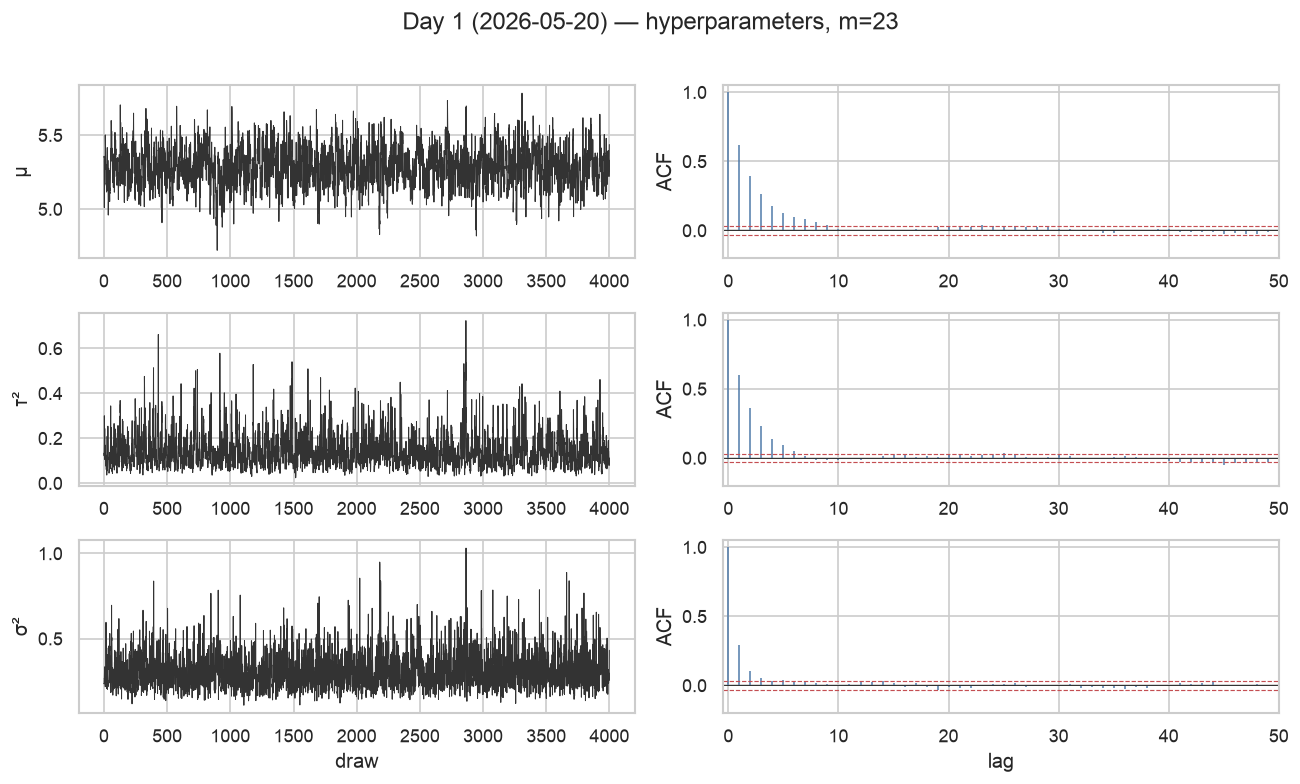

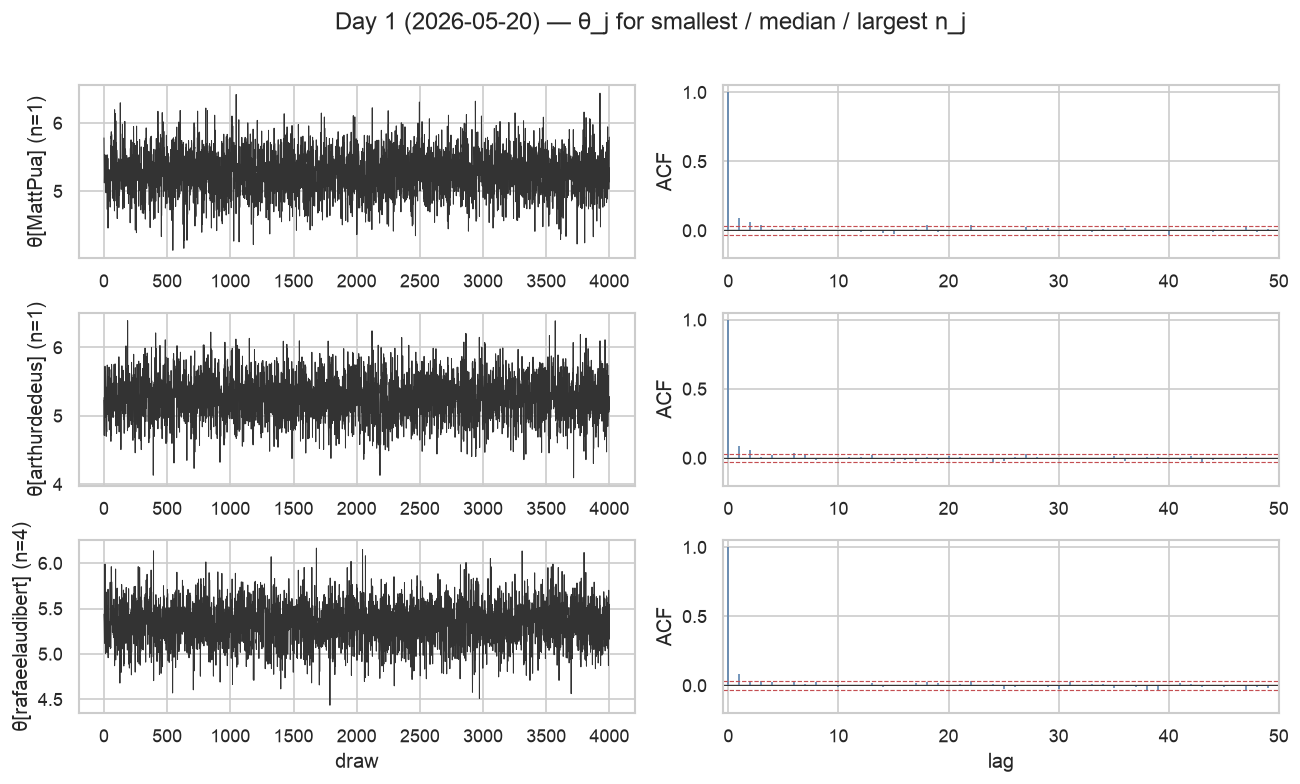

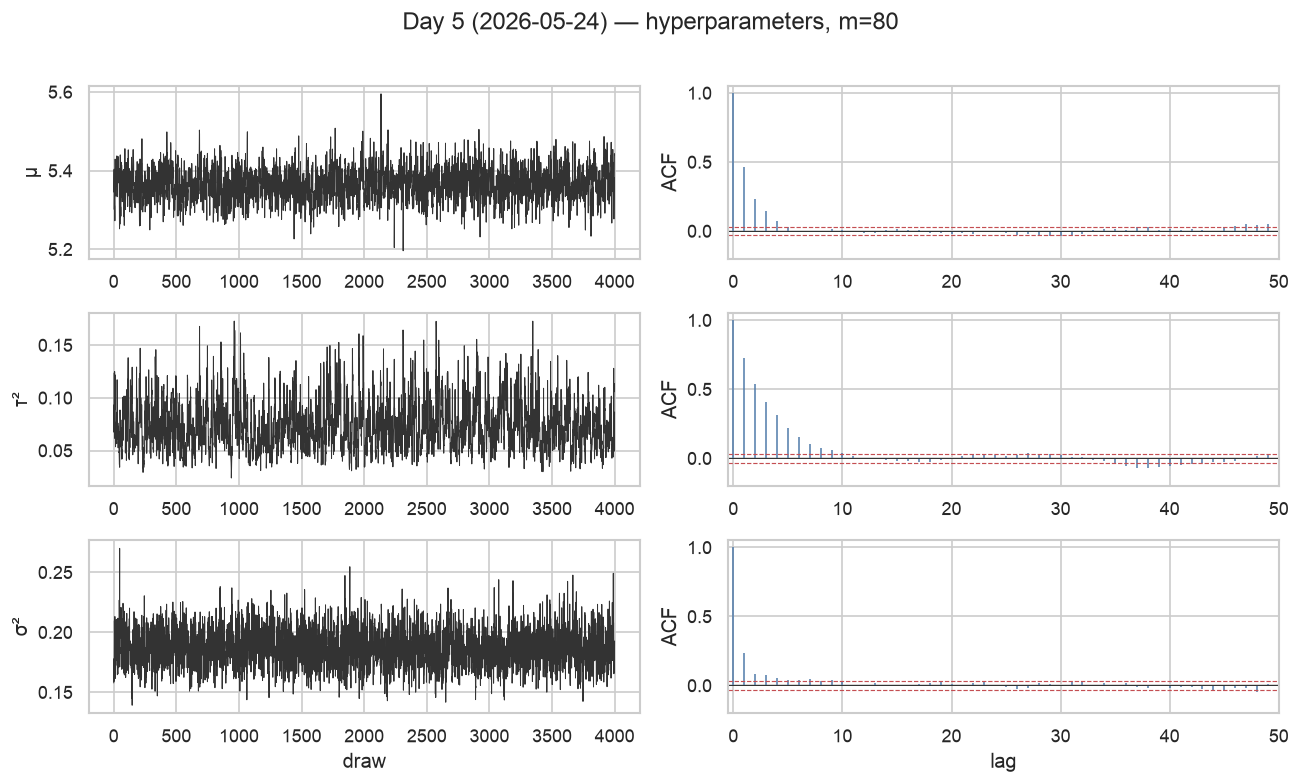

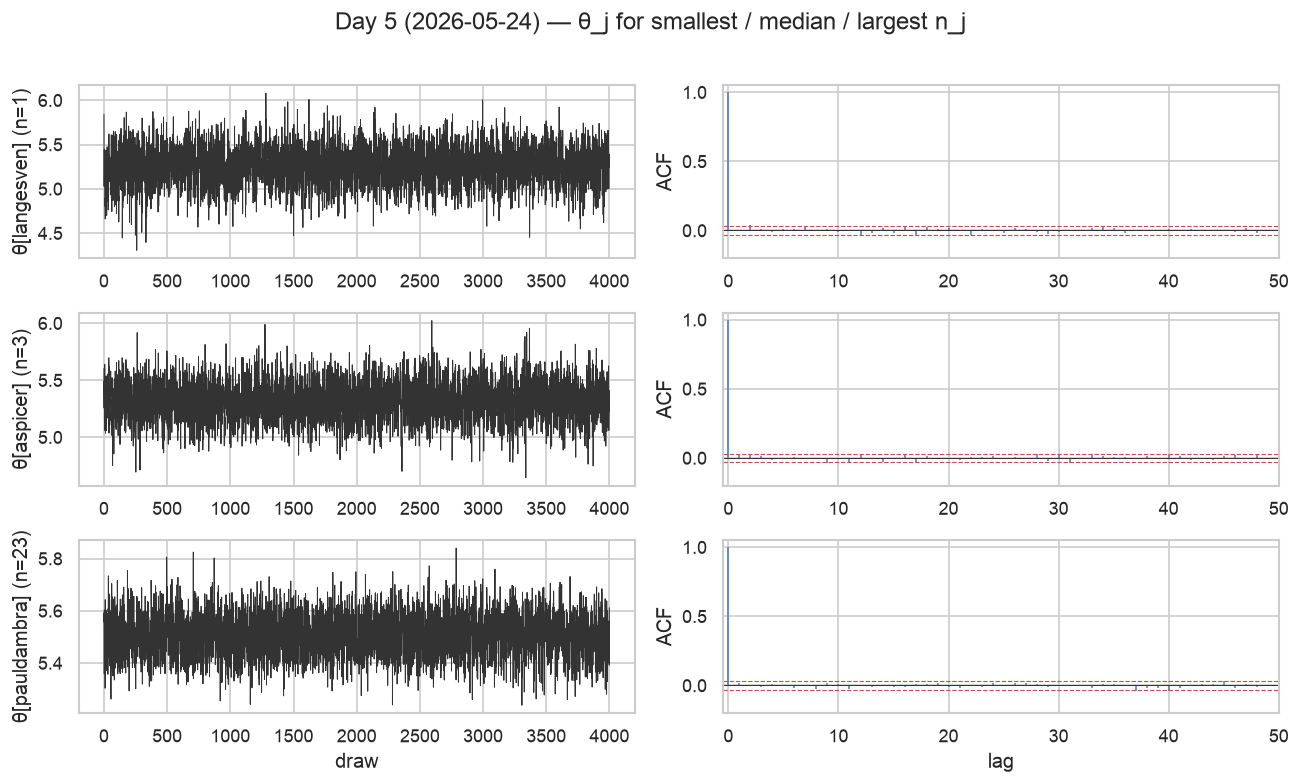

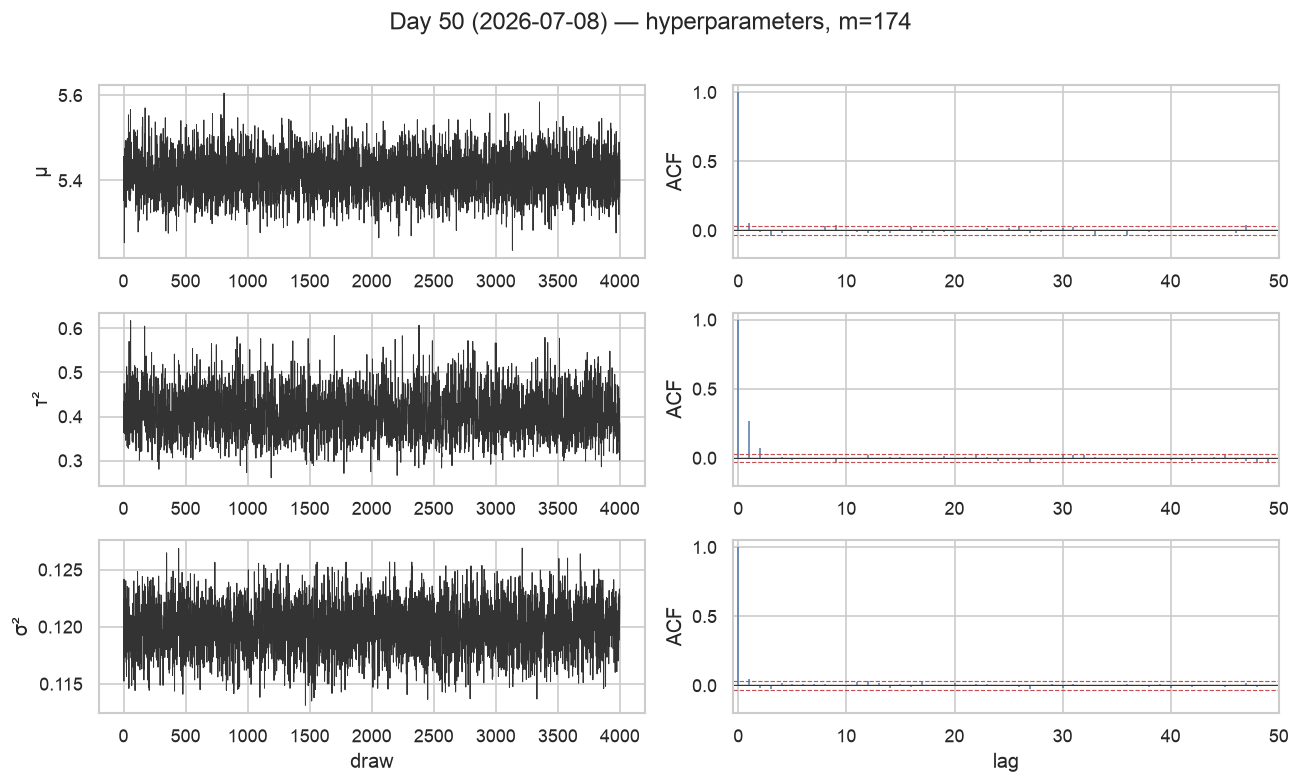

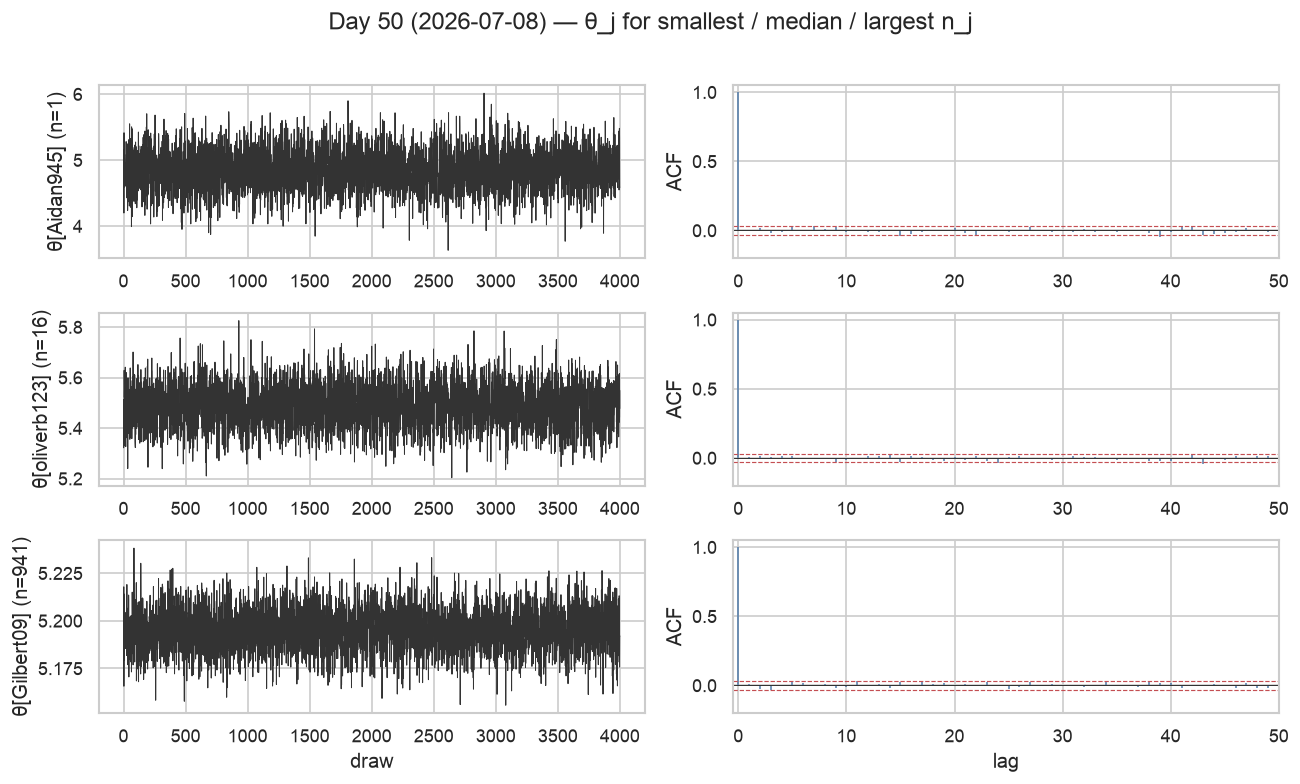

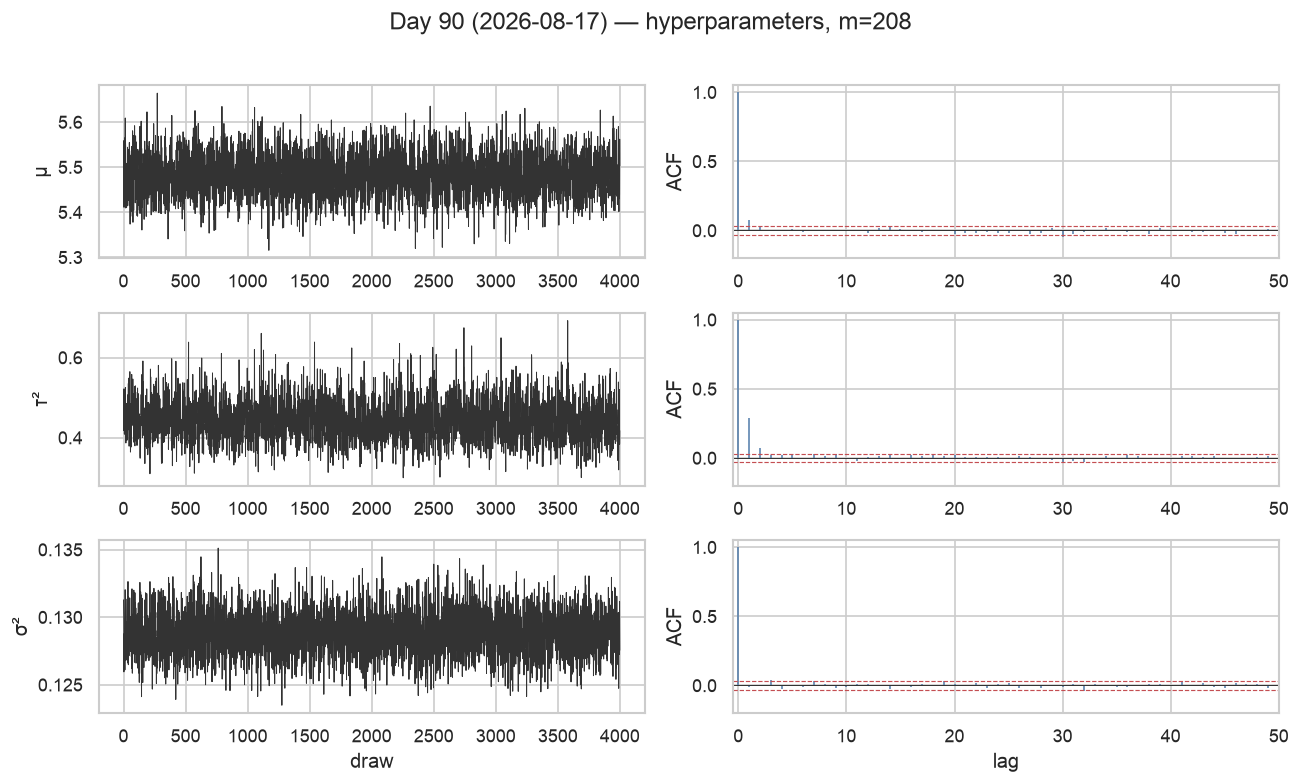

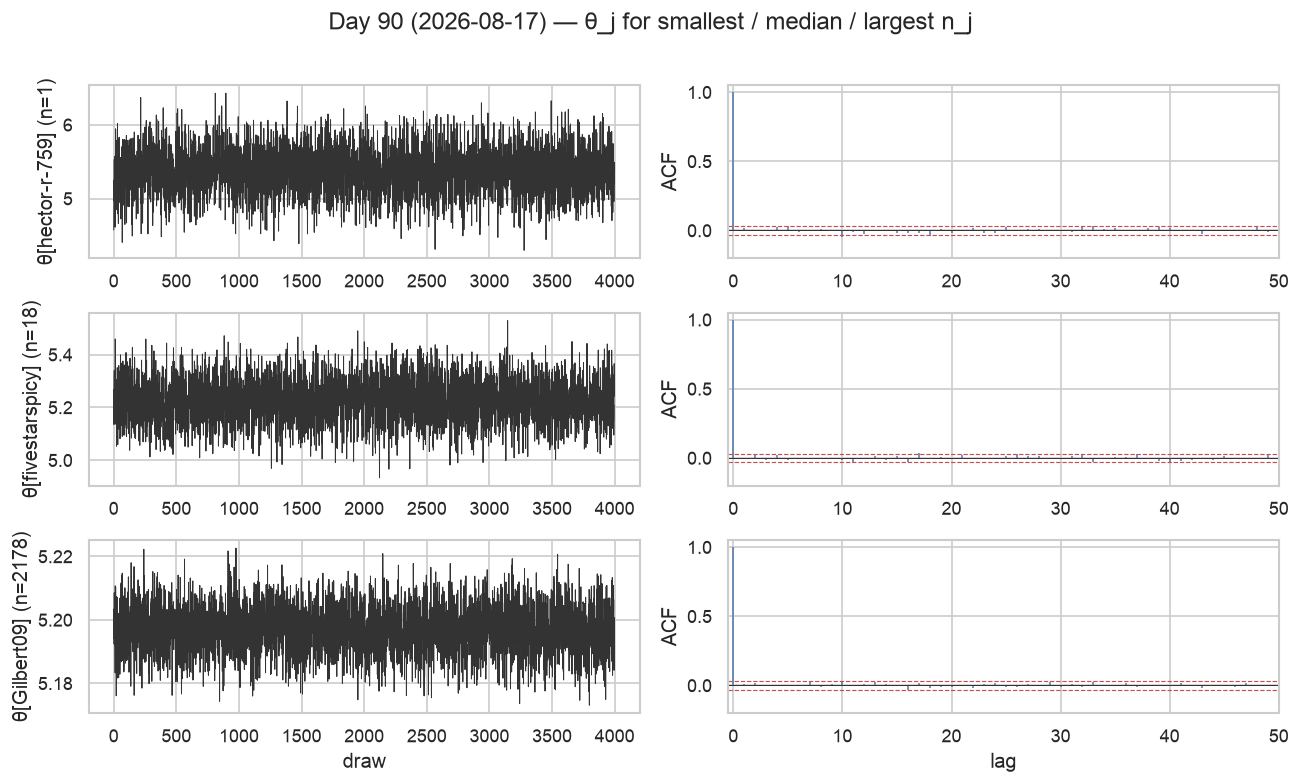

In [4]:
def acf(draws: np.ndarray, nlags: int = 50) -> tuple[np.ndarray, np.ndarray]:
    x = np.asarray(draws, dtype=float)
    x = x - x.mean()
    denom = float(np.dot(x, x))
    lags = np.arange(nlags + 1)
    values = np.empty(nlags + 1, dtype=float)
    values[0] = 1.0
    if denom == 0.0:
        values[1:] = 1.0
        return lags, values
    for lag in range(1, nlags + 1):
        values[lag] = float(np.dot(x[:-lag], x[lag:]) / denom)
    return lags, values


def representative_thetas(fit: GibbsFit) -> list[tuple[str, np.ndarray]]:
    order = np.argsort(fit.n_j)
    picks = [order[0], order[len(order) // 2], order[-1]]
    seen: set[int] = set()
    chosen: list[tuple[str, np.ndarray]] = []
    for idx in picks:
        if int(idx) in seen:
            continue
        seen.add(int(idx))
        name = str(fit.contributors[idx])
        label = f"θ[{name}] (n={int(fit.n_j[idx])})"
        chosen.append((label, fit.theta[:, idx]))
    return chosen


def plot_series_diagnostics(
    series: list[tuple[str, np.ndarray]], title: str, nlags: int = 50
) -> None:
    n = len(series)
    fig, axes = plt.subplots(n, 2, figsize=(11, 2.15 * n), squeeze=False)
    for row, (label, draws) in enumerate(series):
        axes[row, 0].plot(draws, color="#333333", linewidth=0.6)
        axes[row, 0].set_ylabel(label)
        axes[row, 0].set_xlabel("draw" if row == n - 1 else "")
        lags, values = acf(draws, nlags=nlags)
        axes[row, 1].vlines(lags, 0, values, color="#4c78a8", linewidth=0.9)
        axes[row, 1].axhline(0, color="#333333", linewidth=0.6)
        bound = 1.96 / np.sqrt(len(draws))
        axes[row, 1].axhline(bound, color="#c44e52", linewidth=0.7, linestyle="--")
        axes[row, 1].axhline(-bound, color="#c44e52", linewidth=0.7, linestyle="--")
        axes[row, 1].set_xlim(-0.5, nlags)
        axes[row, 1].set_ylim(-0.2, 1.05)
        axes[row, 1].set_xlabel("lag" if row == n - 1 else "")
        axes[row, 1].set_ylabel("ACF")
    fig.suptitle(title, y=1.01)
    fig.tight_layout()
    plt.show()


for day_index in DIAG_DAYS:
    fit = fits[day_index]
    hyper = [
        ("μ", fit.mu),
        ("τ²", fit.tau2),
        ("σ²", fit.sigma2),
    ]
    plot_series_diagnostics(
        hyper,
        f"Day {day_index} ({fit.day.date()}) — hyperparameters, m={len(fit.contributors)}",
    )
    plot_series_diagnostics(
        representative_thetas(fit),
        f"Day {day_index} ({fit.day.date()}) — θ_j for smallest / median / largest n_j",
    )

## 3. Posterior mean θ<sub>j</sub> at days 1, 5, 50, 90

Same expanding-window idea as Section 4 of `commit_impact.ipynb`, but only the four days this notebook fitted, and each point is the **posterior mean of θ<sub>j</sub>** rather than raw ȳ<sub>j</sub>. A contributor's line starts at the first of those four days on which they have a commit — no zeros beforehand. The red line is the posterior mean of μ that day.

This cell reuses `fits` from Section 1 when it is already in the kernel; otherwise it reloads the panel and refits those four days.

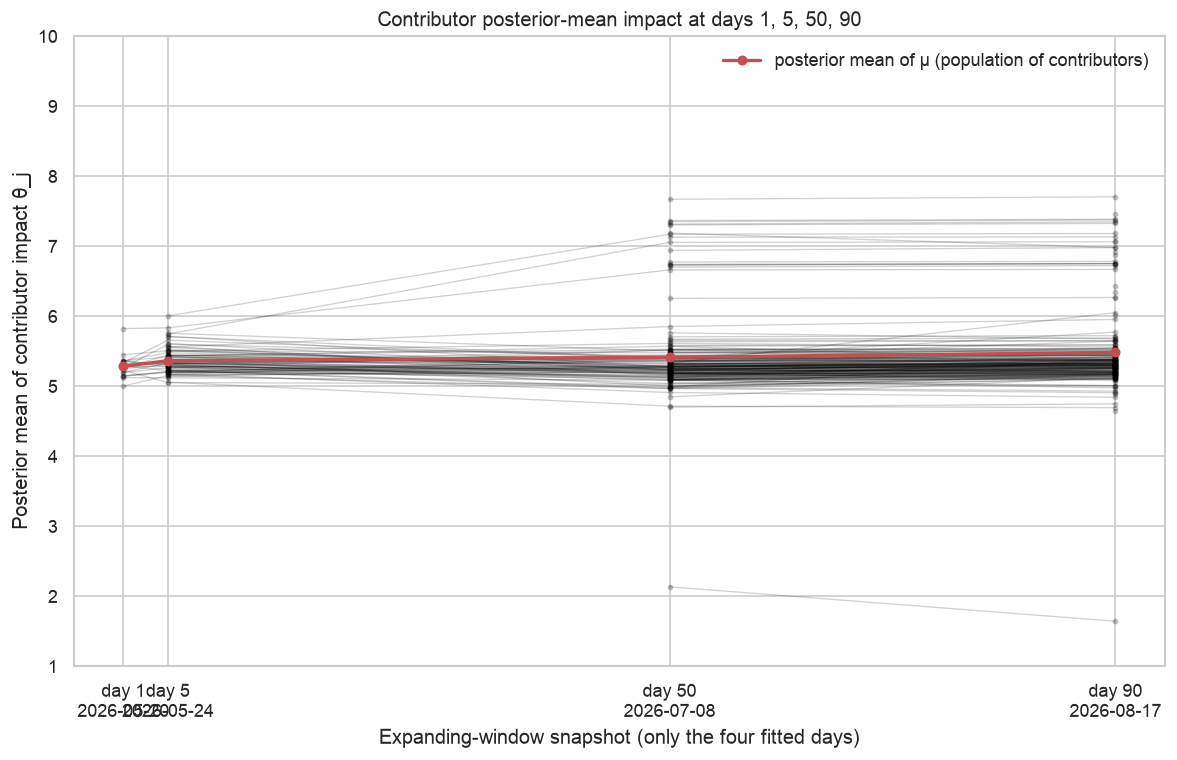

In [5]:
DIAG_DAYS = [1, 5, 50, 90]
N_ITER = 5000
BURN_IN = 1000
SEED = 20260818


def _ensure_fits() -> dict[int, GibbsFit]:
    existing = globals().get("fits")
    if isinstance(existing, dict) and all(day in existing for day in DIAG_DAYS):
        return existing

    def find_repo_root() -> Path:
        here = Path.cwd().resolve()
        marker = Path("github_etl") / "src" / "github_etl" / "schemas.py"
        for candidate in (here, *here.parents):
            if (candidate / marker).exists():
                return candidate
        raise FileNotFoundError("Run Jupyter from the repo root or notebooks/.")

    panel_path = find_repo_root() / "model" / "data" / "daily_contributor_panel.parquet"
    loaded = read_daily_panel(panel_path)
    rebuilt = {
        day_index: fit_day(
            loaded, day_index, n_iter=N_ITER, burn_in=BURN_IN, seed=SEED
        )
        for day_index in DIAG_DAYS
    }
    print(
        "refit "
        + ", ".join(f"day {d} ({rebuilt[d].elapsed_s:.2f}s)" for d in DIAG_DAYS)
    )
    return rebuilt


fits = _ensure_fits()

rows: list[dict] = []
mu_rows: list[dict] = []
for day_index in DIAG_DAYS:
    fit = fits[day_index]
    mu_rows.append(
        {"day_index": day_index, "day": fit.day, "mu_mean": float(fit.mu.mean())}
    )
    for contributor, theta_mean in zip(fit.contributors, fit.theta_mean, strict=True):
        rows.append(
            {
                "day_index": day_index,
                "day": fit.day,
                "contributor": str(contributor),
                "theta_mean": float(theta_mean),
            }
        )

theta_by_day = pd.DataFrame.from_records(rows)
mu_by_day = pd.DataFrame.from_records(mu_rows)
theta_grid = theta_by_day.pivot(
    index="contributor", columns="day_index", values="theta_mean"
).reindex(columns=DIAG_DAYS)
x = [fits[day_index].day.to_pydatetime() for day_index in DIAG_DAYS]

fig, ax = plt.subplots(figsize=(10, 6.5))
for _, row in theta_grid.iterrows():
    ax.plot(
        x,
        row.to_numpy(),
        color="black",
        alpha=0.18,
        linewidth=0.8,
        marker="o",
        markersize=2.5,
    )
ax.plot(
    x,
    mu_by_day["mu_mean"].to_numpy(),
    color="#c44e52",
    linewidth=2.0,
    marker="o",
    markersize=5,
    label="posterior mean of μ (population of contributors)",
)
ax.set_ylim(1, 10)
ax.set_xticks(x)
ax.set_xticklabels([f"day {d}\n{fits[d].day.date()}" for d in DIAG_DAYS])
ax.set_xlabel("Expanding-window snapshot (only the four fitted days)")
ax.set_ylabel("Posterior mean of contributor impact θ_j")
ax.set_title("Contributor posterior-mean impact at days 1, 5, 50, 90")
ax.legend(frameon=False, loc="upper right")
fig.tight_layout()
plt.show()

## 4. All days: save posterior means and 5%/95% credible intervals

Fit one expanding-window model for **every day** in the extract (91 calendar days; day 1 through day 91). Commit aggregation stays on disk (`daily_contributor_panel.parquet`); the 91 Gibbs runs fan out across 8 processes.

The saved table is one row per `(day, contributor)` with data by that day, validated by `DailyThetaSchema`:

- `theta_mean` — posterior mean of contributor impact θ<sub>j</sub>
- `theta_ci_5`, `theta_ci_95` — **5% and 95% posterior credible intervals** for θ<sub>j</sub>
- `mean_impact` — raw ȳ<sub>j</sub> for comparison
- `mu_mean`, `tau2_mean`, `sigma2_mean` — hyperparameter posterior means that day

The plot below is the same expanding-window series as `commit_impact.ipynb` §4, but each line is `theta_mean`. Bands are stored, not drawn (210 overlapping intervals would hide the means).

fitted 91 days (14,756 contributor-days) in 12.5s on 8 processes
wrote /Users/steffen/Documents/posthog_contributor_impact/model/data/theta_by_day.parquet
schema: impact_model.DailyThetaSchema  columns include theta_mean, theta_ci_5, theta_ci_95 (5% and 95% posterior credible intervals)


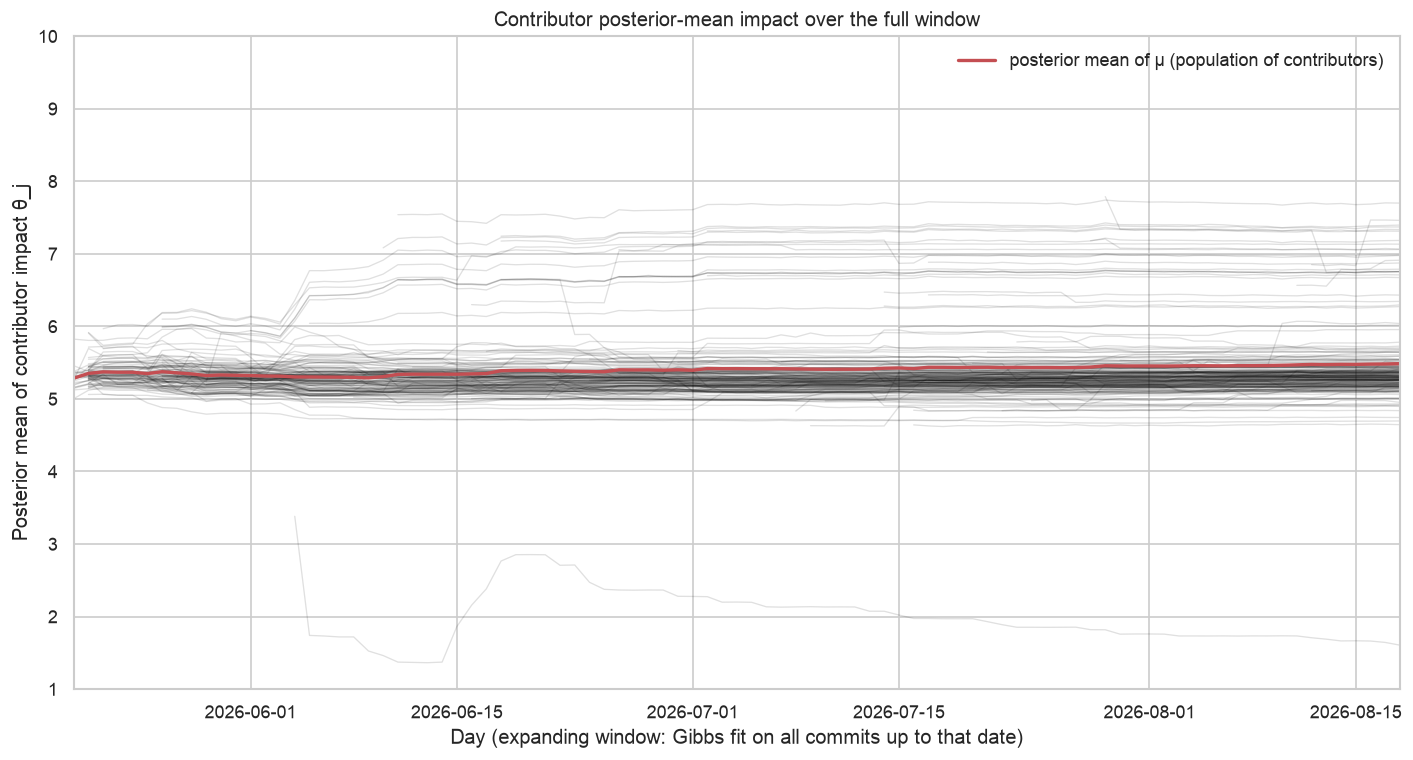

In [6]:
from time import perf_counter

from impact_model import posterior_by_day, read_daily_panel, write_daily_theta

N_ITER = 5000
BURN_IN = 1000
SEED = 20260818
MAX_WORKERS = 8


def find_repo_root() -> Path:
    here = Path.cwd().resolve()
    marker = Path("github_etl") / "src" / "github_etl" / "schemas.py"
    for candidate in (here, *here.parents):
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError("Run Jupyter from the repo root or notebooks/.")


if "PANEL_PATH" not in globals() or "panel" not in globals():
    PANEL_PATH = find_repo_root() / "model" / "data" / "daily_contributor_panel.parquet"
    panel = read_daily_panel(PANEL_PATH)

THETA_PATH = PANEL_PATH.with_name("theta_by_day.parquet")
day_indexes = sorted(int(v) for v in panel["day_index"].unique())

started = perf_counter()
theta_by_day = posterior_by_day(
    panel,
    day_indexes,
    n_iter=N_ITER,
    burn_in=BURN_IN,
    seed=SEED,
    max_workers=MAX_WORKERS,
    panel_path=PANEL_PATH,
)
write_daily_theta(theta_by_day, THETA_PATH)
elapsed = perf_counter() - started

print(
    f"fitted {theta_by_day['day_index'].nunique()} days "
    f"({len(theta_by_day):,} contributor-days) in {elapsed:.1f}s "
    f"on {MAX_WORKERS} processes"
)
print(f"wrote {THETA_PATH}")
print(
    "schema: impact_model.DailyThetaSchema  "
    "columns include theta_mean, theta_ci_5, theta_ci_95 "
    "(5% and 95% posterior credible intervals)"
)

day_order = (
    theta_by_day.drop_duplicates("day_index")
    .sort_values("day_index")[["day_index", "day"]]
)
dates = pd.DatetimeIndex(day_order["day"].to_numpy())
theta_grid = theta_by_day.pivot(
    index="contributor", columns="day_index", values="theta_mean"
).reindex(columns=day_order["day_index"].tolist())
mu_line = (
    theta_by_day.drop_duplicates("day_index")
    .set_index("day_index")
    .loc[day_order["day_index"], "mu_mean"]
)

fig, ax = plt.subplots(figsize=(12, 6.5))
x = dates.to_pydatetime()
for _, row in theta_grid.iterrows():
    ax.plot(x, row.to_numpy(), color="black", alpha=0.12, linewidth=0.8)
ax.plot(
    x,
    mu_line.to_numpy(),
    color="#c44e52",
    linewidth=2.0,
    label="posterior mean of μ (population of contributors)",
)
ax.set_ylim(1, 10)
ax.set_xlim(dates[0], dates[-1])
ax.set_xlabel("Day (expanding window: Gibbs fit on all commits up to that date)")
ax.set_ylabel("Posterior mean of contributor impact θ_j")
ax.set_title("Contributor posterior-mean impact over the full window")
ax.legend(frameon=False, loc="upper right")
fig.tight_layout()
plt.show()